In [2]:
import matplotlib.pyplot as plt
import numpy as np
import csv

In [5]:
def read_file(file):
    x = []
    y = []
    with open(file,'r') as csvfile:
        plots = csv.reader(csvfile, delimiter = ',')
        for row in plots:
            x.append(float(row[0]))
            y.append(float(row[1]))
    return np.array(x), np.array(y)

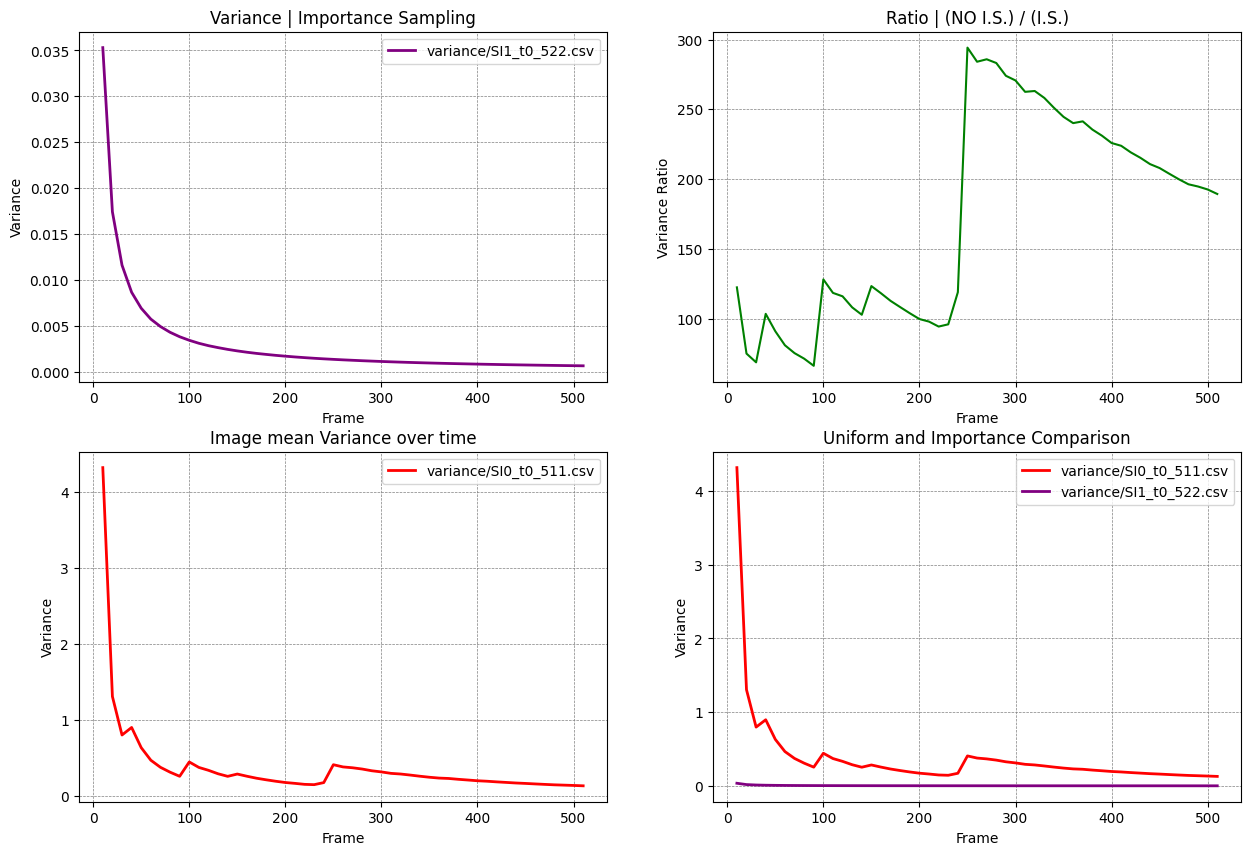

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

file_IS0 = "variance/SI0_t0_511.csv"
frame, y_IS0 = read_file(file_IS0)
file_IS1 = "variance/SI1_t0_522.csv"
_, y_IS1 = read_file(file_IS1)

y_IS1 = y_IS1[:len(y_IS0)]
frame = frame[:len(y_IS0)]
ratio = y_IS0/y_IS1

# IMPORTANCE SAMPLING
axes[0][0].set_title("Variance | Importance Sampling")
axes[0][0].grid(color='gray', linestyle='--', linewidth=0.5)
axes[0][0].plot(frame, y_IS1, color="purple", lw=2.0, label=file_IS1)
axes[0][0].set_xlabel("Frame")
axes[0][0].set_ylabel("Variance")
axes[0][0].legend()
# UNIFORM SAMPLING
axes[1][0].set_title("Variance | Uniform Sampling")
axes[1][0].set_title("Image mean Variance over time")
axes[1][0].grid(color='gray', linestyle='--', linewidth=0.5)
axes[1][0].plot(frame, y_IS0, color="red", lw=2.0, label=file_IS0)
axes[1][0].set_xlabel("Frame")
axes[1][0].set_ylabel("Variance")
axes[1][0].legend()
# BOTH TOGETHER
axes[1][1].set_title("Uniform and Importance Comparison")
axes[1][1].grid(color='gray', linestyle='--', linewidth=0.5)
axes[1][1].plot(frame, y_IS0, color="red", lw=2.0, label=file_IS0)
axes[1][1].plot(frame, y_IS1, color="purple", lw=2.0, label=file_IS1)
axes[1][1].set_xlabel("Frame")
axes[1][1].set_ylabel("Variance")
axes[1][1].legend()
# RATIO
axes[0][1].set_title("Ratio | (NO I.S.) / (I.S.)")
axes[0][1].plot(frame, ratio, color="g", lw=1.5)
axes[0][1].set_xlabel("Frame")
axes[0][1].set_ylabel("Variance Ratio")
axes[0][1].grid(color='gray', linestyle='--', linewidth=0.5)

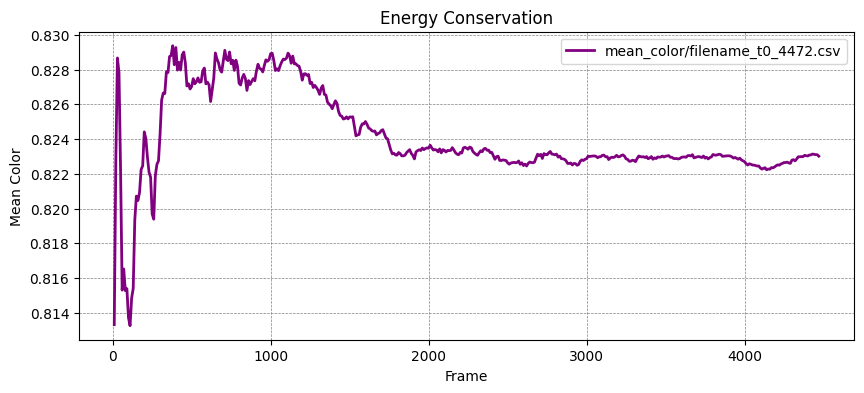

In [18]:
fig, axes = plt.subplots(1, 1, figsize=(10, 4))

file = "mean_color/filename_t0_4472.csv"
t, var = read_file(file)

# IMPORTANCE SAMPLING
axes.set_title("Energy Conservation")
axes.grid(color='gray', linestyle='--', linewidth=0.5)
axes.plot(t, var, color="purple", lw=2.0, label=file)
axes.set_xlabel("Frame")
axes.set_ylabel("Mean Color")
axes.legend()